# What joins Antonelli?

JustFix asked whether the link that reunites Domenico Antonelli's buildings is "based entirely on term-frequency adjustments on names." This notebook answers by tracing his real records through each stage of the engine, so every claim can be checked against the code and the data.

**Short answer: no.** Name rarity matters, but the join happens in two stages, and the second one uses a different kind of evidence.

| Stage | Evidence used | Antonelli's buildings end up in… |
|---|---|---|
| Who Owns What today | shared names and business addresses on HPD registrations | many separate portfolios |
| **Base model** (Splink) | surname + first initial, scored with name rarity and business house number, street and zip | one group per office |
| **Second pass** ("feedback") | the same rare name **and a company shared across the buildings' registrations** | one group |

The counts for each row are computed below. The last row deserves the closest look: for Antonelli the shared company is a property-management firm, which is evidence of a different kind from a name or an address. Steps 7–9 look at how that pass works and how reliable it has been.

**Requirements.** Steps 1, 3–8 need only the HPD tables `hpd_contacts` and `hpd_registrations`. Steps 2, 9 and 10 also read `wow.wow_portfolios` and the ACRIS `real_property_*` tables, and skip with a message if those are absent. Step 4 trains and scores the full population and takes a couple of minutes. Splink's training is stochastic, so pair probabilities can shift slightly between runs.

## Setup

`default_conn()` connects to Postgres (`.env`: `PGHOST/PGPORT/PGDATABASE/PGUSER/PGPASSWORD`) or, with `NLR_SNAPSHOT` set, to a local DuckDB snapshot. The few cells that read tables outside the HPD pair (WoW, ACRIS) use Postgres syntax and go through `try_query`, which skips cleanly if the tables are not there.

In [1]:
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("splink").setLevel(logging.ERROR)

import json, math, pathlib
from collections import defaultdict
import pandas as pd
pd.set_option("display.max_columns", 40, "display.width", 200, "display.max_colwidth", 60)

from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(usecwd=True))

import nlr
from nlr import splink_source as ss
from nlr.resolve import _stratified_train, DEFAULT_THRESHOLD
from nlr.db import default_conn

conn = default_conn()

def try_query(sql, params=None):
    '''Run an optional Postgres query (WoW / ACRIS tables). Returns rows, or None with a note if unavailable.'''
    try:
        cur = conn.cursor(); cur.execute(sql, params); return cur.fetchall()
    except Exception as e:
        try: conn.rollback()
        except Exception: pass
        print("skipped (not available on this connection):", str(e).splitlines()[0]); return None

print("connected; clustering threshold =", DEFAULT_THRESHOLD)

connected; clustering threshold = 0.999


## 1. The records

`ss.extract` reads the HPD owner contacts (`HeadOfficer`, `IndividualOwner`, `CorporateOwner`, `JointOwner`; never agents or managers) and returns **one row per distinct (name, business address)**, with the buildings (`bbls`) that identity registers. Here are Domenico Antonelli's.

In [2]:
full = ss.extract(conn, "TRUE")
full = full[full.contact_kind == "person"].drop_duplicates("unique_id").reset_index(drop=True)
print(f"{len(full):,} person-owner records in the HPD data")

ant = (full[(full.last_name == "ANTONELLI") & full.first_name.fillna("").str.startswith("DOM")]
       .sort_values(["biz_zip", "biz_street_norm", "biz_house"]).reset_index(drop=True))
ant["rec"] = [chr(65 + i) for i in range(len(ant))]          # A, B, C … so pair tables stay readable
ant_bbls = sorted({str(b).strip() for bs in ant.bbls for b in bs})
print(f"Domenico Antonelli: {len(ant)} records covering {len(ant_bbls)} buildings")
ant[["rec", "name_full", "biz_house", "biz_street", "biz_zip", "n_bbls"]]

145,412 person-owner records in the HPD data
Domenico Antonelli: 9 records covering 10 buildings


,rec,name_full,biz_house,biz_street,biz_zip,n_bbls
0,A,DOMENICO ANTONELLI,146-28,27TH AVENUE,11354,1
1,B,DOMENICO ANTONELLI,14648,28TH AVENUE,11354,1
2,C,DOMENICO ANTONELLI,14652,28TH AVENUE,11354,1
3,D,DOMENICO ANTONELLI,10-03,147TH STREET,11357,1
4,E,DOMENICO ANTONELLI,21-27,154TH STREET,11357,1
5,F,DOMENICO ANTONELLI,15056,20TH ROAD,11357,1
6,G,DOMENICO ANTONELLI,21-48,FRANCIS LEWIS BOULEVARD,11357,1
7,H,DOMENICO ANTONELLI,150-115,POWELLS COVE BOULEVARD,11357,2
8,I,DOMENICO ANTONELLI,150-115,POWELLS COW B,11357,1


One name, nine records. The business addresses differ: several offices in two ZIP codes, and one office spelled two ways (`POWELLS COVE BOULEVARD` and `POWELLS COW B`). A system that links on exact name-and-address matches sees these as separate people.

## 2. What Who Owns What does with them

WoW groups buildings through shared names and shared business addresses on the registrations. Looking up each Antonelli building in `wow.wow_portfolios` shows where that leaves him.

In [3]:
def wow_portfolios_for(bbls):
    '''{portfolio id: [bbls]} for every WoW portfolio that contains any of ``bbls``.'''
    rows = try_query('''SELECT orig_id, bbls FROM wow.wow_portfolios
                        WHERE EXISTS (SELECT 1 FROM unnest(bbls) b WHERE btrim(b::text) = ANY(%s))''', (list(bbls),))
    return {str(o): [str(b).strip() for b in bl] for o, bl in rows} if rows else {}

wow = wow_portfolios_for(ant_bbls)
bbl_wow = {b: pid for pid, bl in wow.items() for b in bl}
ant["wow_portfolio"] = [", ".join(sorted({bbl_wow.get(str(b).strip(), "?") for b in bs})) for bs in ant.bbls]
ant["wow_size"] = [max(len(wow.get(bbl_wow.get(str(b).strip()), [])) for b in bs) for bs in ant.bbls]
n_wow = len({bbl_wow.get(b) for b in ant_bbls} - {None})
print(f"{len(ant_bbls)} buildings sit in {n_wow} separate WoW portfolios")
ant[["rec", "biz_house", "biz_street", "biz_zip", "wow_portfolio", "wow_size"]]

10 buildings sit in 9 separate WoW portfolios


,rec,biz_house,biz_street,biz_zip,wow_portfolio,wow_size
0,A,146-28,27TH AVENUE,11354,25790,1
1,B,14648,28TH AVENUE,11354,25791,1
2,C,14652,28TH AVENUE,11354,25792,1
3,D,10-03,147TH STREET,11357,25789,1
4,E,21-27,154TH STREET,11357,25796,1
5,F,15056,20TH ROAD,11357,25795,1
6,G,21-48,FRANCIS LEWIS BOULEVARD,11357,25797,1
7,H,150-115,POWELLS COVE BOULEVARD,11357,25793,2
8,I,150-115,POWELLS COW B,11357,25794,1


## 3. Which records are even compared? (blocking)

Splink does not compare every pair of records. nlr uses **one** blocking rule: the two records must share a **surname and first initial**. A surname match is the entry ticket; it is never sufficient by itself, as the next steps show.

The model also needs to know how common the name is, both for term-frequency weighting and for the common-name veto (step 6). `ss.name_freq` counts the distinct identities per (surname, initial).

In [4]:
nf = ss.name_freq(conn)
n_same = int(nf[(nf.last_name == "ANTONELLI") & (nf.first_initial == "D")].identities.iloc[0])
print(f"identities sharing (ANTONELLI, D): {n_same}   [Domenico's own records: {len(ant)}]")
print(f"candidate pairs among Domenico's records: {len(ant) * (len(ant) - 1) // 2}")
print("a (surname, initial) shared by more than 15 identities counts as a COMMON name (veto, step 6)")

identities sharing (ANTONELLI, D): 10   [Domenico's own records: 9]
candidate pairs among Domenico's records: 36
a (surname, initial) shared by more than 15 identities counts as a COMMON name (veto, step 6)


## 4. Train and score

`fit_predict_full` learns the match weights on a dense training slice and then scores every candidate pair in the full population. Each comparison contributes **bits of evidence**: name (surname and first name, with a term-frequency adjustment so a rare name counts for more), and business address (house number, street, ZIP). This is the longest cell.

In [5]:
import contextlib, io
train = _stratified_train(full)
degrees = ss.address_degrees(conn)      # real full-population address degrees, for the aggregator-address mask
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):   # mute Splink's EM log
    linker, preds = ss.fit_predict_full(train, full, addr_degrees=degrees)
p = preds.as_pandas_dataframe()
print(f"{len(p):,} scored pairs at match probability >= 0.5")

29,407 scored pairs at match probability >= 0.5


## 5. Scoring Antonelli's pairs

For each pair of his records: the evidence from the **name** (surname, first name, plus their term-frequency adjustments), the evidence from the **address** (house number, street, ZIP), and the resulting match probability. Splink's *match weight* is the sum of the evidence plus a negative prior (two random records are very unlikely to match).

In [6]:
ids = dict(zip(ant.unique_id, ant.rec))
pp = p[p.unique_id_l.isin(ids) & p.unique_id_r.isin(ids)].copy()
bits = lambda col: pp[col].map(lambda v: math.log2(v) if v and v > 0 else 0.0)
pp["pair"] = ["–".join(sorted([l, r])) for l, r in zip(pp.unique_id_l.map(ids), pp.unique_id_r.map(ids))]
pp["name_bits"] = sum(bits(c) for c in ["bf_last_name", "bf_tf_adj_last_name", "bf_first_name", "bf_tf_adj_first_name"])
pp["tf_bits"] = bits("bf_tf_adj_last_name") + bits("bf_tf_adj_first_name")
pp["address_bits"] = sum(bits(c) for c in ["bf_biz_house", "bf_biz_street_norm", "bf_biz_zip", "bf_tf_adj_biz_zip"])
pp["prior_bits"] = pp.match_weight - pp.name_bits - pp.address_bits
pp["merged_at_threshold"] = (pp.match_probability >= DEFAULT_THRESHOLD) & (pp.gamma_first_name != 0)
show = ["pair", "match_probability", "name_bits", "tf_bits", "address_bits", "prior_bits", "match_weight", "merged_at_threshold"]
print(f"{len(pp)} of the {len(ant) * (len(ant) - 1) // 2} candidate pairs score >= 0.5")
pp.sort_values("match_probability", ascending=False)[show].round(3).reset_index(drop=True)

18 of the 36 candidate pairs score >= 0.5


,pair,match_probability,name_bits,tf_bits,address_bits,prior_bits,match_weight,merged_at_threshold
0,H–I,1.000,21.069,6.102,22.965,-17.969,26.066,True
1,B–C,1.000,21.069,6.102,15.618,-17.969,18.718,True
2,A–C,1.000,21.069,6.102,9.851,-17.969,12.951,True
3,A–B,1.000,21.069,6.102,9.851,-17.969,12.951,True
4,D–E,0.999,21.069,6.102,7.500,-17.969,10.601,True
5,E–G,0.994,21.069,6.102,4.236,-17.969,7.336,False
6,G–H,0.972,21.069,6.102,2.014,-17.969,5.114,False
7,D–F,0.972,21.069,6.102,2.014,-17.969,5.114,False
8,D–I,0.972,21.069,6.102,2.014,-17.969,5.114,False
9,D–H,0.972,21.069,6.102,2.014,-17.969,5.114,False


Read the columns left to right:

- **`name_bits`** is the same for every pair: same surname, same first name, and a rare name. `tf_bits` is the part of it that comes from term-frequency adjustment, a minority of the name evidence.
- **`address_bits`** is what separates the pairs. Records at the same or near-identical address (the `POWELLS COW B` typo, `14648` versus `14652` 28th Avenue) gain many bits and clear the 0.999 threshold. One pair of different streets in the same ZIP with similar street names (`D–E`) also clears it, narrowly.
- Pairs at unrelated addresses sit near 0.97 (`prior_bits` plus `name_bits` plus a matching ZIP at best): probably the same person, but below the bar. The model is deliberately conservative: a rare name at a different office is likely, not near-certain.

### Waterfall charts: the pairs that decide the outcome

A Splink [waterfall chart](https://moj-analytical-services.github.io/splink/charts/waterfall_chart.html) draws one pair's score as a staircase. It starts at the **prior** (about −18 bits, because two random records almost never match); each bar then adds (green) or subtracts (red) the evidence from one comparison, and the last bar is the **match weight**. A pair needs a final weight of about 10 bits to reach a 0.999 match probability (printed above each chart). Four pairs tell the story:

| Pair | Why it matters |
|---|---|
| H–I | the same office spelled two ways (`POWELLS COVE BOULEVARD` / `POWELLS COW B`): house number, street and ZIP all agree, a clear merge |
| D–E | different house numbers and different streets (`147TH` / `154TH`) in the same ZIP: merges, but by well under a bit |
| E–G | similar house numbers but different streets: a near miss, a few bits short |
| D–F | a typical cross-office pair: house number and street both disagree, only the name and ZIP agree, about 5 bits short |

H–I:  match weight 26.1 bits  vs  10.0 needed for 0.999   ->  MERGED


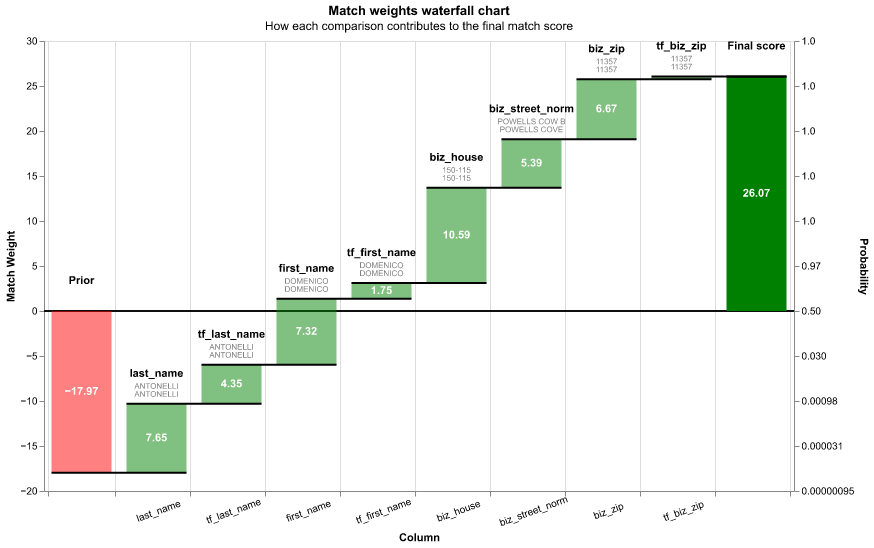

D–E:  match weight 10.6 bits  vs  10.0 needed for 0.999   ->  MERGED


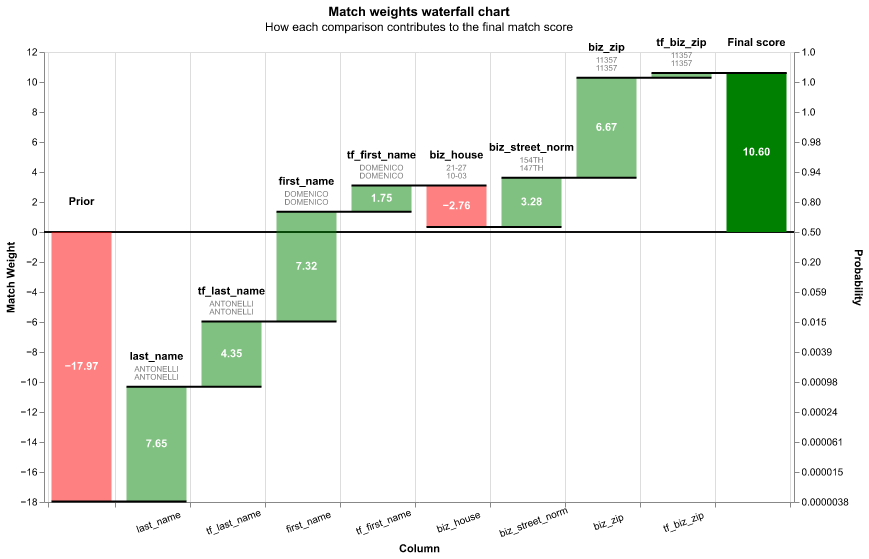

E–G:  match weight 7.3 bits  vs  10.0 needed for 0.999   ->  not merged


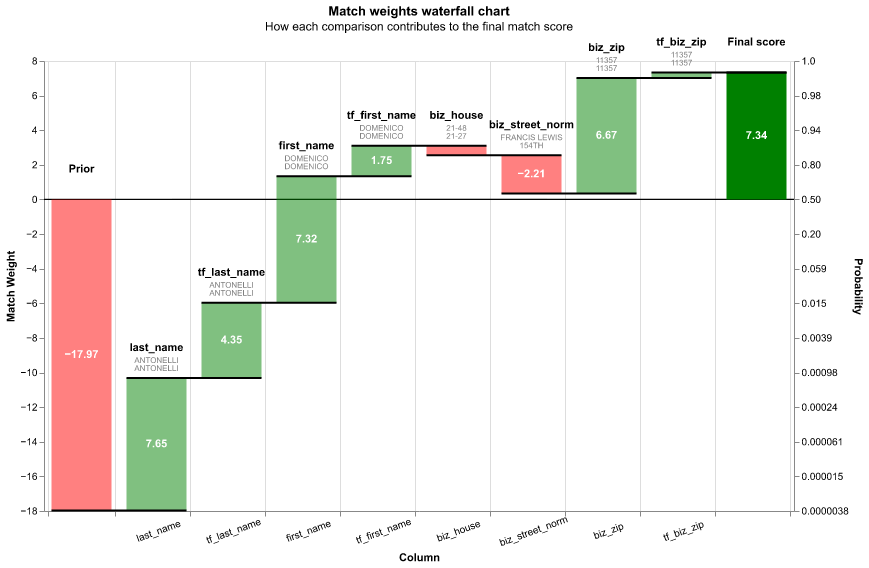

D–F:  match weight 5.1 bits  vs  10.0 needed for 0.999   ->  not merged


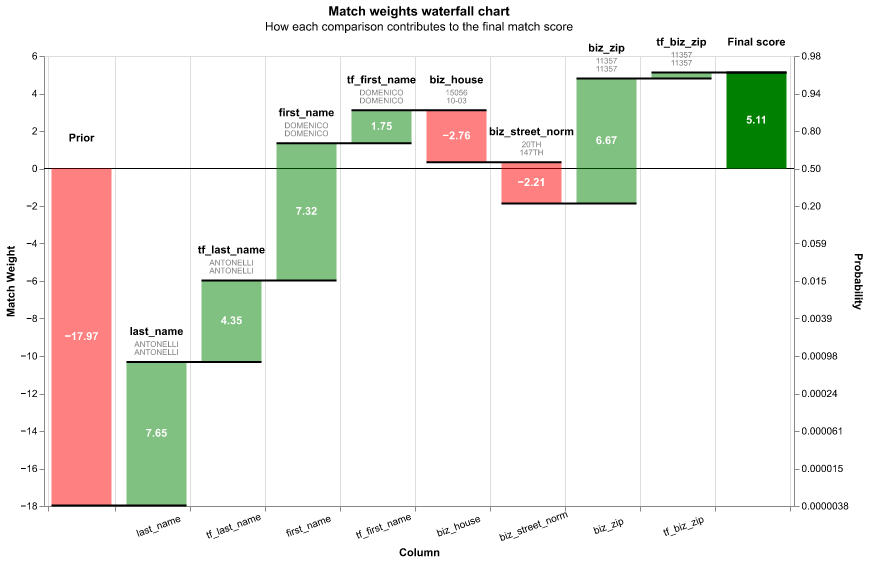

In [7]:
import altair as alt
alt.renderers.enable("png")      # rasterize locally via vl-convert, so the charts render in any notebook viewer

thr_bits = math.log2(DEFAULT_THRESHOLD / (1 - DEFAULT_THRESHOLD))      # match weight that equals probability 0.999

def waterfall(pair):
    row = pp[pp.pair == pair].iloc[0]
    verdict = "MERGED" if row.merged_at_threshold else "not merged"
    print(f"{pair}:  match weight {row.match_weight:.1f} bits  vs  {thr_bits:.1f} needed for {DEFAULT_THRESHOLD}   ->  {verdict}")
    display(linker.visualisations.waterfall_chart([row.to_dict()]))

for pair in ["H–I", "D–E", "E–G", "D–F"]:
    waterfall(pair)

**What the four charts show**

- **The name evidence is identical in all four**: last name and first name agree, and the two term-frequency bars add a little over 6 bits for how rare the name is. Those bars matter: they lift a name match from improbable (about −3 bits without them) to probable (about +3 bits with them). They do not get a pair anywhere near the ~10 bits needed to merge.
- **A matching ZIP is worth about +6.7 bits** in this model, which is why even the cross-office pairs (`D–F`) reach about 5 bits and a 0.97 probability.
- **House number and street decide the outcome.** `H–I` gains about 16 bits from them. The pairs at different addresses lose bits (red bars), and that gap is what keeps Antonelli's offices apart in the base model.
- **A caveat on the street comparison.** It measures string similarity, so numbered streets such as `147TH` and `154TH` look alike. That nudged `D–E` over the bar; here the merge is correct, but it shows the threshold is a bright line drawn through evidence of uneven quality.

No cross-office pair clears the bar on name and ZIP alone. That is the gap the second pass (step 7) fills.

## 6. Threshold and vetoes: the base groups

`cluster_gated` keeps a pair when its probability is at least 0.999 **and** two precision vetoes allow it:

- **First-name veto**: the first names must not genuinely disagree (JACOB and JOSEF at one office are different people).
- **Common-name veto**: a *common* name at *different* addresses is not merged on name alone (two unrelated JIN CHENs).

Connected pairs form groups.

In [8]:
base = ss.cluster_gated(preds, full, DEFAULT_THRESHOLD, name_freq=nf)
base_of = base.set_index("unique_id").cluster_id
grp = {g: i + 1 for i, g in enumerate(base_of.reindex(ant.unique_id).drop_duplicates())}
ant["base_group"] = base_of.reindex(ant.unique_id).map(grp).values
print(f"base model: {ant.base_group.nunique()} groups  (was {n_wow} WoW portfolios; common-name veto applies only above 15 identities, here {n_same})")
ant[["rec", "biz_house", "biz_street", "biz_zip", "wow_portfolio", "base_group"]]

base model: 5 groups  (was 9 WoW portfolios; common-name veto applies only above 15 identities, here 10)


,rec,biz_house,biz_street,biz_zip,wow_portfolio,base_group
0,A,146-28,27TH AVENUE,11354,25790,1
1,B,14648,28TH AVENUE,11354,25791,1
2,C,14652,28TH AVENUE,11354,25792,1
3,D,10-03,147TH STREET,11357,25789,2
4,E,21-27,154TH STREET,11357,25796,2
5,F,15056,20TH ROAD,11357,25795,3
6,G,21-48,FRANCIS LEWIS BOULEVARD,11357,25797,4
7,H,150-115,POWELLS COVE BOULEVARD,11357,25793,5
8,I,150-115,POWELLS COW B,11357,25794,5


The base model repairs splits between **variants of the same or neighboring addresses** (a typo, a dropped hyphen, adjacent house numbers) and stops there. Offices at unrelated addresses stay separate, because a name plus, at best, a matching ZIP is not enough evidence for a 0.999 match. Name-and-address scoring alone cannot reunite all of his offices.

## 7. The second pass: a shared company on the registrations

`feedback_merge` merges two groups when **all** of these hold:

1. same surname and first initial, and the first names are compatible;
2. the name is **rare** (at most 15 identities for that surname and initial);
3. the groups' buildings share a **company name that appears on their registrations**, and that company is not on too many different contacts' records (a cap of 25 distinct named contacts, to exclude big aggregators).

First, what do Antonelli's registrations name?

In [9]:
rows = try_query('''
  WITH ch AS (SELECT DISTINCT ON (btrim(bbl)) btrim(bbl) AS bbl, registrationid
              FROM hpd_registrations WHERE bbl IS NOT NULL
              ORDER BY btrim(bbl), registrationenddate DESC NULLS LAST, lastregistrationdate DESC NULLS LAST)
  SELECT c.type, CASE WHEN nullif(btrim(c.corporationname), '') IS NOT NULL THEN upper(btrim(c.corporationname))
                      WHEN c.type = 'IndividualOwner' THEN upper(btrim(c.firstname) || ' ' || btrim(c.lastname))
                      ELSE '(named individual)' END AS name,
         count(DISTINCT ch.bbl) AS buildings
  FROM ch JOIN hpd_contacts c USING (registrationid)
  WHERE ch.bbl = ANY(%s) GROUP BY 1, 2 ORDER BY 3 DESC, 1''', (ant_bbls,))
pd.DataFrame(rows, columns=["contact type", "name", "buildings"]) if rows else None

,contact type,name,buildings
0,IndividualOwner,DOMENICO ANTONELLI,10
1,SiteManager,(named individual),10
2,Agent,CAROLLO MANAGEMENT,9
3,Agent,CAROLLO,1
4,Lessee,NA,1


He is the registered `IndividualOwner` of all ten buildings, and the **same management company is the registered `Agent`** on (nearly) all of them. That company name is the bridge the second pass uses. Which company names does it consider on his buildings, and how common is each?

In [10]:
CAP = 25
corp_df = ss.corp_owners_for(conn)          # (bbl, company): every company named on any building's registration
corp_deg = ss.corp_degrees(conn)            # company -> distinct named contacts listed under that company name
ca = corp_df[corp_df.bbl.isin(ant_bbls)].merge(corp_deg, on="corp")
(ca.groupby("corp").agg(buildings=("bbl", "nunique"), degree=("degree", "first")).reset_index()
   .assign(under_cap=lambda d: d.degree <= CAP).sort_values("buildings", ascending=False).reset_index(drop=True))

,corp,buildings,degree,under_cap
0,CAROLLO MANAGEMENT,9,2,True
1,CAROLLO,1,1,True


Note what `degree` measures: the number of distinct *named contacts* listed under that company name across HPD, not the number of clients. It is a rough aggregator filter.

Now check the pairwise rule directly: which companies (under the cap) are shared by **every** one of the base groups?

In [11]:
ok_corps = set(corp_deg[corp_deg.degree <= CAP].corp)
corps_by_bbl = corp_df[corp_df.corp.isin(ok_corps)].groupby("bbl").corp.apply(set).to_dict()
group_corps = {}
for g, sub in ant.groupby("base_group"):
    bs = {str(b).strip() for bl in sub.bbls for b in bl}
    group_corps[g] = set().union(*[corps_by_bbl.get(b, set()) for b in bs])
for g, cs in group_corps.items():
    print(f"base group {g}: companies on its buildings (under cap) = {sorted(cs)}")
print("\nshared by ALL groups:", sorted(set.intersection(*group_corps.values())))

base group 1: companies on its buildings (under cap) = ['CAROLLO MANAGEMENT']
base group 2: companies on its buildings (under cap) = ['CAROLLO MANAGEMENT']
base group 3: companies on its buildings (under cap) = ['CAROLLO MANAGEMENT']
base group 4: companies on its buildings (under cap) = ['CAROLLO MANAGEMENT']
base group 5: companies on its buildings (under cap) = ['CAROLLO', 'CAROLLO MANAGEMENT']

shared by ALL groups: ['CAROLLO MANAGEMENT']


In [12]:
final = ss.feedback_merge(full, base, corp_df, corp_deg, name_freq=nf)    # corp_cap=25, name_cap=15 are the defaults
final_of = final.set_index("unique_id").cluster_id
ant["final_group"] = final_of.reindex(ant.unique_id).map({g: i + 1 for i, g in enumerate(final_of.reindex(ant.unique_id).drop_duplicates())}).values
print(f"after the second pass: {ant.final_group.nunique()} group")
ant[["rec", "biz_house", "biz_street", "biz_zip", "wow_portfolio", "base_group", "final_group"]]

after the second pass: 1 group


,rec,biz_house,biz_street,biz_zip,wow_portfolio,base_group,final_group
0,A,146-28,27TH AVENUE,11354,25790,1,1
1,B,14648,28TH AVENUE,11354,25791,1,1
2,C,14652,28TH AVENUE,11354,25792,1,1
3,D,10-03,147TH STREET,11357,25789,2,1
4,E,21-27,154TH STREET,11357,25796,2,1
5,F,15056,20TH ROAD,11357,25795,3,1
6,G,21-48,FRANCIS LEWIS BOULEVARD,11357,25797,4,1
7,H,150-115,POWELLS COVE BOULEVARD,11357,25793,5,1
8,I,150-115,POWELLS COW B,11357,25794,5,1


## 8. Putting it together

In [13]:
summary = pd.DataFrame({
    "stage": ["Who Owns What (today)", "Base model (name + address)", "Base model + second pass"],
    "groups for Antonelli's buildings": [n_wow, ant.base_group.nunique(), ant.final_group.nunique()],
    "evidence": ["shared name / business address on registrations",
                 "surname + first initial, scored on name rarity and house/street/zip",
                 "same rare name + a company shared across the registrations"],
})
summary

,stage,groups for Antonelli's buildings,evidence
0,Who Owns What (today),9,shared name / business address on registrations
1,Base model (name + address),5,"surname + first initial, scored on name rarity and house..."
2,Base model + second pass,1,same rare name + a company shared across the registrations


To get the middle row from the public API, call `owner_index(conn, feedback=False)`; the default (`feedback=True`) adds the second pass. The WoW patch currently calls `owner_index(conn)`, so it includes both stages.

So: **name rarity is one input to the first stage, and it is not what joins Antonelli's offices.** The cross-office join is the second pass, and its evidence for him is a shared management company.

## 9. How reliable is the second pass?

First, what kind of company is it? Here is the bridge company across all of HPD:

In [14]:
rows = try_query('''SELECT c.type, count(DISTINCT btrim(r.bbl)) AS buildings,
                           count(DISTINCT upper(btrim(c.firstname)) || '|' || upper(btrim(c.lastname))) AS named_contacts
                    FROM hpd_contacts c JOIN hpd_registrations r USING (registrationid)
                    WHERE upper(btrim(c.corporationname)) = 'CAROLLO MANAGEMENT' GROUP BY 1''')
pd.DataFrame(rows, columns=["contact type", "buildings", "named contacts"]) if rows else None

,contact type,buildings,named contacts
0,Agent,84,2


It is an `Agent`, a management company that appears on registrations for many buildings, not an owner of record. The second pass does not distinguish between a company that *owns* and one that *manages*.

To see how often that kind of bridge is right, use the repo's labeled evaluation sample. `nlr/eval/frame_gold.jsonl` holds 150 stratified pairs the model links (stratum `S2_model`), each labeled by hand against HPD registrations and ACRIS (one human annotator). We keep the pairs whose two sides sit in **different WoW portfolios**, since those are the links a patch would add, and split them by how they were linked: base model, or second pass.

In [15]:
gold = [json.loads(l) for l in (pathlib.Path(nlr.__file__).parent / "eval" / "frame_gold.jsonl").open()]
s2 = [r for r in gold if r["stratum"] == "S2_model"]
s2_bbls = sorted({str(b).strip() for r in s2 for k in ("a_bbls", "b_bbls") for b in r[k]})
wow_s2 = wow_portfolios_for(s2_bbls)
bbl_wow2 = {b: pid for pid, bl in wow_s2.items() for b in bl}

by_name = defaultdict(list)
for u, nm, bl in zip(full.unique_id, full.name_full, full.bbls):
    by_name[nm].append((u, {str(b).strip() for b in bl}))
base_all = base.set_index("unique_id").cluster_id.to_dict()
members = base.groupby("cluster_id").unique_id.apply(list).to_dict()
bbls_of = dict(zip(full.unique_id, full.bbls))
deg = corp_deg.set_index("corp").degree.to_dict()

def recs(name, bbls):
    bs = {str(b).strip() for b in bbls}
    return [u for u, x in by_name.get(name, []) if x & bs]

def group_corps_of(cid):
    bs = {str(b).strip() for u in members[cid] for b in bbls_of[u]}
    return set().union(*[corps_by_bbl.get(b, set()) for b in bs])

def bridge(ga, gb):
    '''Least-common company shared by a base group on each side: (company, degree).'''
    best = None
    for x in ga:
        for y in gb:
            for k in group_corps_of(x) & group_corps_of(y):
                if best is None or (deg[k], k) < (best[1], best[0]): best = (k, deg[k])
    return best

def contact_types(company, bbls):
    rows = try_query('''SELECT DISTINCT c.type FROM hpd_contacts c JOIN hpd_registrations r USING (registrationid)
                        WHERE upper(btrim(c.corporationname)) = %s AND btrim(r.bbl) = ANY(%s)''', (company, list(bbls)))
    return "+".join(t for (t,) in rows) if rows else "?"

out, unmapped = [], 0
for r in s2:
    pa = {bbl_wow2.get(str(b).strip()) for b in r["a_bbls"]}; pb = {bbl_wow2.get(str(b).strip()) for b in r["b_bbls"]}
    if None in pa | pb or pa & pb:
        continue                                   # WoW already groups them (or not mapped): not a new link
    A, B = recs(r["a_name"], r["a_bbls"]), recs(r["b_name"], r["b_bbls"])
    if not A or not B:
        unmapped += 1; continue
    ga, gb = {base_all[u] for u in A}, {base_all[u] for u in B}
    row = dict(pair=r["pair_id"], label=r["label"], same_full_name=(r["a_name"] == r["b_name"]), link="base model" if ga & gb else "second pass",
               wow_max=max(len(wow_s2[p]) for p in pa | pb), bridge_degree=None, bridge_types=None)
    if row["link"] == "second pass":
        b = bridge(ga, gb)
        if b:
            row["bridge_degree"] = b[1]
            row["bridge_types"] = contact_types(b[0], {str(x).strip() for g in ga | gb for u in members[g] for x in bbls_of[u]})
    out.append(row)
res = pd.DataFrame(out)
print(f"{len(res)} sampled links join pairs that WoW keeps in separate portfolios ({unmapped} unmapped)")

def wilson(k, n, z=1.96):
    p_ = k / n; d = 1 + z * z / n
    c = (p_ + z * z / (2 * n)) / d; h = z * math.sqrt(p_ * (1 - p_) / n + z * z / (4 * n * n)) / d
    return f"{c - h:.0%}–{c + h:.0%}"

tab = res.groupby("link").label.agg(pairs="count", correct=lambda s: int((s == "SAME").sum()))
tab["wrong"] = tab.pairs - tab.correct
tab["precision"] = (tab.correct / tab.pairs).map("{:.0%}".format)
tab["95% interval"] = [wilson(k, n) for k, n in zip(tab.correct, tab.pairs)]
tab

67 sampled links join pairs that WoW keeps in separate portfolios (0 unmapped)


,pairs,correct,wrong,precision,95% interval
link,,,,,
base model,49,49,0,100%,93%–100%
second pass,18,15,3,83%,61%–94%


In [16]:
# The second-pass links one by one (names withheld): were the two records the same full name, how big was the WoW
# portfolio on the larger side, how many named contacts does the bridge company have, and what kind of contact is it?
# (A blank bridge means the two groups were joined indirectly, through a third group.)
res[res.link == "second pass"].sort_values("bridge_degree")[["pair", "label", "same_full_name", "wow_max", "bridge_degree", "bridge_types"]].reset_index(drop=True)

,pair,label,same_full_name,wow_max,bridge_degree,bridge_types
0,P0170,SAME,False,26,1.0,Agent
1,P0219,SAME,True,4,1.0,Agent
2,P0256,SAME,True,1,1.0,Agent
3,P0195,SAME,True,2,1.0,Agent
4,P0132,SAME,True,1,1.0,Agent+CorporateOwner
5,P0222,SAME,True,13,1.0,Agent+CorporateOwner
6,P0220,SAME,True,14,1.0,Agent+CorporateOwner
7,P0135,SAME,True,23,1.0,Agent+CorporateOwner
8,P0204,SAME,True,10,2.0,Agent+CorporateOwner
9,P0205,SAME,True,3,2.0,Agent


How to read this table honestly:

- **Small samples, and an after-the-fact split.** The base-versus-second-pass split was made after the errors were known, so treat the contrast as a lead, not a measurement. A fresh labeled sample would be needed to confirm it.
- **Labels** are one human annotator's (the committed fixture). A second, blind human reader is planned.
- In the sample, every error among the cross-portfolio links is a second-pass link, between two records with the same full name (see `same_full_name`), bridged by a management company (`Agent`), with a WoW portfolio of 50+ buildings on one side.
- The second-pass links that were right include bridges where the shared company also appears as an owner of record (`CorporateOwner` in the last column). A shared *owner* company is ownership evidence; a shared *manager* is not.

That is why a more conservative first version is worth considering: ship the base-model links, and make the shared-company pass a separate, labeled edge type.

## 10. A caveat that applies to every registration-based portfolio

Registrations say who is *registered*, not who owns the building today. Checking ACRIS for deeds in which his estate is the seller:

In [17]:
rows = try_query('''
  SELECT btrim(l.bbl) AS bbl, m.docdate AS deed_date, m.docamount AS amount
  FROM real_property_master m JOIN real_property_legals l USING (documentid)
  WHERE m.doctype ILIKE '%%DEED%%' AND btrim(l.bbl) = ANY(%s)
    AND EXISTS (SELECT 1 FROM real_property_parties p
                WHERE p.documentid = m.documentid AND p.partytype = 1
                  AND upper(p.name) LIKE 'ESTATE OF DOMENICO ANTONELLI%%')
  ORDER BY 1, 2''', (ant_bbls,))
if rows is not None:
    sold = pd.DataFrame(rows, columns=["bbl", "deed_date", "amount"])
    print(f"{sold.bbl.nunique()} of {len(ant_bbls)} buildings have a deed in which the Estate of Domenico Antonelli is the seller")
    display(sold)

3 of 10 buildings have a deed in which the Estate of Domenico Antonelli is the seller


,bbl,deed_date,amount
0,4042200050,2024-04-24,1320000
1,4046750036,2024-03-27,1100000
2,4057750015,2024-06-13,975000


The HPD registrations still list him on all ten buildings, but ACRIS shows his estate selling some of them in 2024 (table above). A portfolio built from registrations, WoW's or this engine's, is only as current as those registrations. That is another reason to present portfolios as leads that point to records, and to show the evidence beside them.

## Takeaways

1. **Term-frequency name rarity is one input, not the whole story.** Reaching a 0.999 match needs address agreement as well, and a name alone scores below the threshold.
2. **Antonelli's offices are joined by the second pass**, on the strength of a shared management company plus a rare name, the same pattern a person would notice by eye.
3. **That pass is the weaker part of the method** in the labeled sample, because a shared manager is not ownership evidence. Treat it separately from the name-and-address links.
4. **Registrations lag reality.** Check deeds before relying on a portfolio as a statement of current ownership.